# Phase 6: Grad-CAM Interpretability and Shortcut Audit

This notebook does **not train a new model**. It loads the weighted DenseNet-121 checkpoint selected in Phase 4/5, generates Grad-CAM explanations for confident true-positive test examples, and exports a simple shortcut-risk audit based on border activation.

The concrete outputs from this run are:

- `gradcam_gallery.png`
- `shortcut_border_fraction.csv`

**Headline result:** measured against the ~0.42 score a *uniform* heatmap would give, **all 14 diseases fall below the line** — no border/text shortcut is detected — and the per-disease ordering tracks anatomy (Cardiomegaly the most central at `0.066`; diffuse/peripheral findings like Emphysema `0.387` and Effusion `0.262` the most spread). The model attends peripherally only when the pathology itself is peripheral.

## 1. Install Grad-CAM

The notebook uses `pytorch-grad-cam` for class-specific heatmaps. On Kaggle this dependency is installed at runtime, so internet access must be enabled for this cell.


In [1]:
!pip install grad-cam -q 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Imports, labels, and dataset wrapper

This setup reuses the same dataset contract from the earlier modeling phases: each row points to an image file and carries 14 independent disease labels. Images are opened as RGB and later resized to `224 x 224` with ImageNet normalization.


In [2]:
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.transforms import Compose
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report)
from timeit import default_timer as timer
import numpy as np
import warnings
  # Kaggle: internet must be ON

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

warnings.filterwarnings("ignore")

# Instantly mounts the entire image folder system-wide in the background
# It returns the root directory containing all the 'images_001', 'images_002', etc. subfolders.
dataset_root_dir = Path(kagglehub.dataset_download("nih-chest-xrays/data"))

print(f"The images folder is mounted at: {dataset_root_dir}")

target_cols = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
       'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
       'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


class ChestImageDataset(Dataset):
    def __init__(self, csv_url,target_cols=target_cols, transforms=None):
        self.data = pd.read_csv(csv_url)
        self.target_cols  = target_cols
        self.transforms = transforms
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        
        # Instant O(1) path lookup
        img_path = row['full_path']
        
        # Open and standardise image channels
        image = Image.open(img_path).convert("RGB")
        
        # Extract your one-hot columns
        labels = row[self.target_cols].values.astype('float32')
        labels = torch.tensor(labels)
        
        if self.transforms:
            image = self.transforms(image)
            
        return image, labels

The images folder is mounted at: /kaggle/input/datasets/organizations/nih-chest-xrays/data


## 3. Select the compute device

Grad-CAM performs gradient passes through DenseNet-121, so GPU execution is preferred. This run selected `cuda`.


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else"cpu")
DEVICE

device(type='cuda')

## 4. Define preprocessing transforms

The interpretability pass keeps preprocessing identical to Phase 4/5 evaluation: resize to `224 x 224`, convert to tensor, and normalize with ImageNet mean and standard deviation.


In [4]:
eval_transform = Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_transform = eval_transform

## 5. Build and sanity-check the training split

The training split is loaded for pipeline consistency. The shape check should return one image tensor shaped `[3, 224, 224]` and one 14-label target vector.


In [5]:
train_dataset = ChestImageDataset(
    csv_url = "/kaggle/input/datasets/aarshdesai05/chest-xray-data/train_data.csv",  
    transforms=train_transform
)
image,labels = train_dataset[0]
print(image.shape)
print(labels.shape)

torch.Size([3, 224, 224])
torch.Size([14])


The preview image confirms that the exported `full_path` values still resolve to real X-ray files in the attached NIH image dataset.


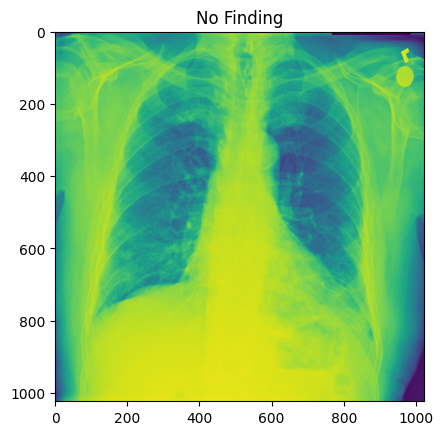

In [6]:
row = train_dataset.data.iloc[3]
img = Image.open(row["full_path"])
positive = [c for c in train_dataset.target_cols if row[c] == 1]
title = ", ".join(positive) if positive else "No Finding"
plt.imshow(img)
plt.title(title)
plt.show()

## 6. Build and sanity-check the validation split

Validation data is not used to tune anything in this phase, but it remains attached so the notebook mirrors the earlier project pipeline.


In [7]:
val_dataset = ChestImageDataset(
    csv_url = "/kaggle/input/datasets/aarshdesai05/chest-xray-data/val_data.csv",  
    transforms=eval_transform
)

image,labels = val_dataset[0]
print(image.shape)
print(labels.shape)

torch.Size([3, 224, 224])
torch.Size([14])


The validation preview is a second path and label sanity check before moving to the held-out test split.


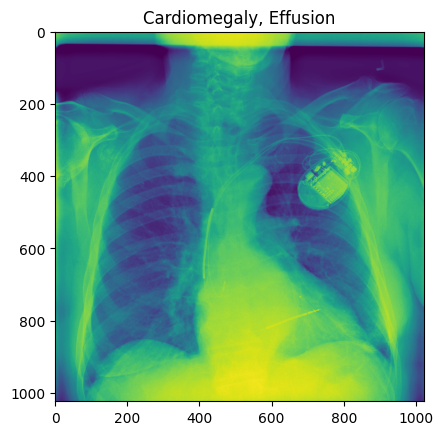

In [8]:
row = val_dataset.data.iloc[3]
img = Image.open(row["full_path"])
positive = [c for c in val_dataset.target_cols if row[c] == 1]
title = ", ".join(positive) if positive else "No Finding"
plt.imshow(img)
plt.title(title)
plt.show()

## 7. Build and sanity-check the test split

The held-out test split is the source of all Grad-CAM examples and the shortcut audit. The loader is not shuffled later, so dataset indices line up with the stored prediction arrays.


In [9]:
test_dataset = ChestImageDataset(
    csv_url = "/kaggle/input/datasets/aarshdesai05/chest-xray-data/test_data.csv",  
    transforms=eval_transform
)
image,labels = test_dataset[0]
print(image.shape)
print(labels.shape)

torch.Size([3, 224, 224])
torch.Size([14])


The test preview confirms that the final evaluation split is accessible before Grad-CAM examples are selected from it.


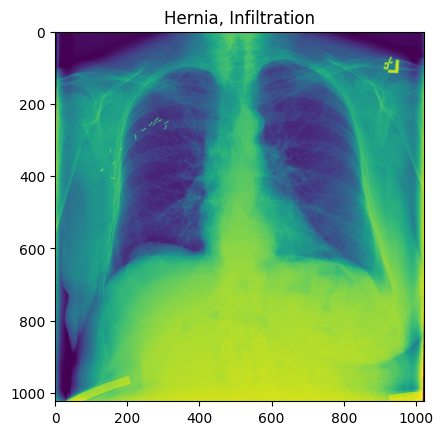

In [10]:
row = test_dataset.data.iloc[3]
img = Image.open(row["full_path"])
positive = [c for c in test_dataset.target_cols if row[c] == 1]
title = ", ".join(positive) if positive else "No Finding"
plt.imshow(img)
plt.title(title)
plt.show()

## 8. Build data loaders

All loaders use `batch_size=64` and `num_workers=4`, matching the previous DenseNet evaluation setup. The printed batch shapes confirm the model input contract: `[B, 3, 224, 224]` images and `[B, 14]` labels.


In [11]:
train_data = DataLoader(train_dataset,batch_size=64,shuffle=True,num_workers=4)

In [12]:
images, labels = next(iter(train_data))
print(images.shape, labels.shape)

torch.Size([64, 3, 224, 224]) torch.Size([64, 14])


In [13]:
val_data = DataLoader(val_dataset,batch_size=64,num_workers=4)

In [14]:
images,labels = next(iter(val_data))
print(images.shape,labels.shape)

torch.Size([64, 3, 224, 224]) torch.Size([64, 14])


In [15]:
test_data = DataLoader(test_dataset,batch_size=64,num_workers=4)

In [16]:
images,labels = next(iter(test_data))
print(images.shape,labels.shape)

torch.Size([64, 3, 224, 224]) torch.Size([64, 14])


## 9. Load the weighted DenseNet-121 checkpoint

DenseNet-121 is rebuilt without downloading ImageNet weights, the classifier is replaced with a 14-output head, and the Phase 4 weighted checkpoint is loaded. This is the deployment candidate evaluated at `0.7970` test macro-AUROC in the earlier result tables.


In [17]:
from torchvision.models import densenet121, DenseNet121_Weights
backbone = densenet121(weights=None)
backbone.classifier = nn.Linear(backbone.classifier.in_features,out_features=14,bias=True)
model = backbone.to(DEVICE)    
model.load_state_dict(torch.load("/kaggle/input/models/aarshdesai05/weighted-model/pytorch/default/1/densenet_finetune_weighted.pt", map_location=DEVICE, weights_only=True))
model.eval()
print("weights loaded ✓")

weights loaded ✓


## 10. Define a test scoring helper

`evaluate()` collects sigmoid probabilities and labels across a loader. Those probability arrays are later used to select confident true-positive examples for each disease.


In [18]:
def evaluate(loader):
    all_scores, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(torch.float32).to(DEVICE)
            probs  = torch.sigmoid(model(images))     # [B,14] probabilities
            all_scores.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_labels, 0), np.concatenate(all_scores, 0)

## 11. Configure Grad-CAM

The target layer is `model.features.norm5`, the final convolution-stage normalization layer before DenseNet's global pooling. It preserves enough spatial structure for heatmaps while still representing high-level disease evidence.


In [19]:
# DenseNet-121: the last conv-stage output is model.features.norm5 (the final BN before global pool)
target_layers = [model.features.norm5]
cam = GradCAM(model=model, target_layers=target_layers)   # NOTE: do NOT wrap in no_grad — CAM needs gradients
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

The helper below reverses ImageNet normalization so overlays can be drawn on a visually interpretable RGB image.


In [20]:
_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(img_tensor):
    rgb = (img_tensor.cpu() * _std + _mean).permute(1, 2, 0).numpy()
    return np.clip(rgb, 0, 1)

`gradcam_for()` computes the heatmap for one test image and one disease logit, then returns the original image, raw Grad-CAM map, and colored overlay.


In [21]:
def gradcam_for(dataset_idx, disease_idx):
    img_tensor, _ = test_dataset[dataset_idx]              # [3,224,224], normalized
    input_tensor  = img_tensor.unsqueeze(0).to(DEVICE)
    targets       = [ClassifierOutputTarget(disease_idx)] # explains the logit for THIS disease
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]   # [224,224], 0..1
    rgb     = denorm(img_tensor)
    overlay = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)
    return rgb, grayscale_cam, overlay

## 12. Score the test split and select confident true positives

The test loader order is stable, so each probability row maps back to the same `test_dataset` index. `top_examples()` filters to true-positive cases for a target disease and selects the highest-confidence examples.


In [22]:
y_true_test, y_score_test = evaluate(test_data)   # order matches test_dataset (no shuffle)

def top_examples(disease_idx, n=3):
    pos = np.where(y_true_test[:, disease_idx] == 1)[0]          # truly has the disease
    pos = pos[np.argsort(-y_score_test[pos, disease_idx])]       # most confident first
    return pos[:n]

## 13. Create the Grad-CAM gallery

The gallery shows two confident true-positive examples each for Cardiomegaly, Effusion, Pneumothorax, and Edema. Each pair contains the original image and the class-targeted Grad-CAM overlay. This run saved the figure as `gradcam_gallery.png`.


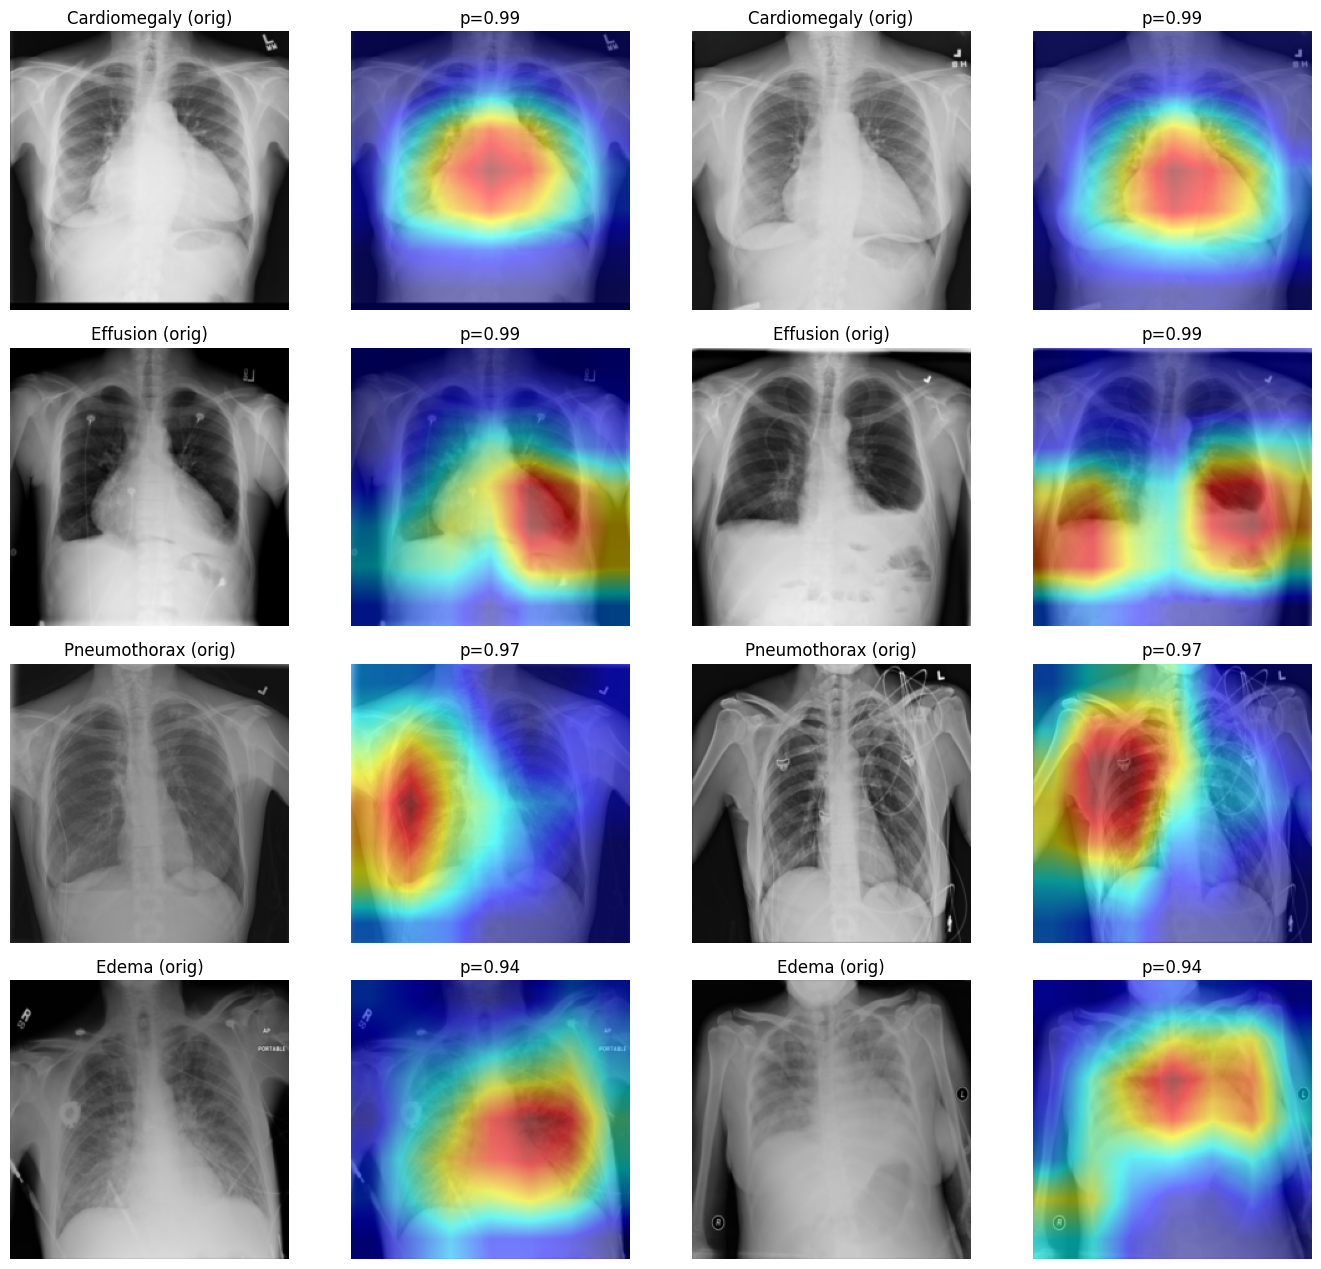

In [23]:
diseases_to_show = ["Cardiomegaly", "Effusion", "Pneumothorax", "Edema"]

fig, axes = plt.subplots(len(diseases_to_show), 4, figsize=(14, 3.2*len(diseases_to_show)))
for r, dname in enumerate(diseases_to_show):
    d_idx = target_cols.index(dname)
    idxs  = top_examples(d_idx, n=2)
    col = 0
    for ex in idxs:
        rgb, gcam, overlay = gradcam_for(ex, d_idx)
        axes[r, col].imshow(rgb);     axes[r, col].set_title(f"{dname} (orig)"); axes[r, col].axis("off")
        axes[r, col+1].imshow(overlay); axes[r, col+1].set_title(f"p={y_score_test[ex,d_idx]:.2f}"); axes[r, col+1].axis("off")
        col += 2
plt.tight_layout(); plt.savefig("/kaggle/working/gradcam_gallery.png", dpi=120, bbox_inches="tight"); plt.show()

### Gallery interpretation

The actual gallery is mixed in the useful way expected from an interpretability check:

- Cardiomegaly heatmaps are centered over the cardiac silhouette, matching the very low border score reported later.
- Effusion and Pneumothorax examples activate relevant lower/lateral chest regions, but some activation reaches image edges.
- Edema examples show broader thoracic activation with some edge spill.

These qualitative findings motivate the quantitative border-fraction audit below.


## 14. Quantify border activation

`border_fraction()` measures the share of Grad-CAM mass in the outer 12% image frame. For each disease, the notebook averages that value over up to 10 confident true-positive examples.

This score is a shortcut-risk proxy, not a diagnosis of shortcut use. A high value means the class deserves closer visual review for border, marker, device, cropping, or acquisition artifacts.


In [24]:
def border_fraction(gcam, border=0.12):
    H, W = gcam.shape
    b = int(H * border)
    ring = np.ones_like(gcam, dtype=bool)
    ring[b:H-b, b:W-b] = False           # True only on the outer frame
    return gcam[ring].sum() / (gcam.sum() + 1e-9)

# average border fraction across confident true positives for each disease
rows = []
for dname in target_cols:
    d_idx = target_cols.index(dname)
    fr = [border_fraction(gradcam_for(ex, d_idx)[1]) for ex in top_examples(d_idx, n=10)]
    rows.append({"disease": dname, "mean_border_frac": round(float(np.mean(fr)), 3)})
shortcut_df = pd.DataFrame(rows).sort_values("mean_border_frac", ascending=False)
shortcut_df.to_csv("/kaggle/working/shortcut_border_fraction.csv", index=False)
shortcut_df

,disease,mean_border_frac
5,Emphysema,0.387
4,Effusion,0.262
13,Pneumothorax,0.259
10,Nodule,0.243
11,Pleural_Thickening,0.203
3,Edema,0.201
9,Mass,0.192
2,Consolidation,0.191
0,Atelectasis,0.187
8,Infiltration,0.183


### Border-fraction results

The exported `shortcut_border_fraction.csv` from this run is:

| Rank | Disease | Mean border fraction |
|---:|---|---:|
| 1 | Emphysema | 0.387 |
| 2 | Effusion | 0.262 |
| 3 | Pneumothorax | 0.259 |
| 4 | Nodule | 0.243 |
| 5 | Pleural_Thickening | 0.203 |
| 6 | Edema | 0.201 |
| 7 | Mass | 0.192 |
| 8 | Consolidation | 0.191 |
| 9 | Atelectasis | 0.187 |
| 10 | Infiltration | 0.183 |
| 11 | Fibrosis | 0.174 |
| 12 | Pneumonia | 0.150 |
| 13 | Hernia | 0.087 |
| 14 | Cardiomegaly | 0.066 |

**Key finding — no border-shortcut, and the ordering tracks anatomy.**

*First, the baseline.* The border ring (outer 12% on each side) covers **~42% of the image area**, so a heatmap spread **uniformly** across the image would score `~0.42`. **Every one of the 14 diseases is below that line** (highest: Emphysema 0.387; mean: 0.199). No class concentrates on the frame where burnt-in text and laterality markers live — so there is **no evidence of a border/text shortcut** on this model.

*Second, the ordering — the more convincing signal.* It matches where each pathology actually appears:

- **Cardiomegaly is lowest (0.066):** the enlarged heart is dead-center, so attention should be maximally central. ✓
- **Emphysema / Effusion / Pneumothorax are highest (0.26–0.39):** these are diffuse or peripheral findings (whole-lung hyperinflation, costophrenic-angle fluid, peripheral lung edge), so activation *should* reach toward the periphery. ✓

The model attends **peripherally when the disease is peripheral and centrally when it is central** — the opposite of a shortcut. That per-disease anatomical consistency is the strongest evidence here that the model learned real chest anatomy rather than framing artifacts.

*Caveats:* `mean_border_frac` is a shortcut-risk *proxy*, not proof. A below-uniform score rules out a gross border shortcut but not subtler artifact reliance (e.g. support devices inside the lung fields), and Grad-CAM is coarse for multi-label targets. The elevated peripheral classes still merit a visual spot-check even though their elevation is anatomically expected.